In [1]:
train_splited_path = "../dataset/output/train_splited"
test_splited_path = "../dataset/output/test_splited"
valid_splited_path = "../dataset/output/valid_splited"

LABELS = [' Diff_Direction',' Non_Pedestrain',' Opp_Direction',' Running',' Sitting',' Sleeping',' Standing']

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation and preprocessing
batch_size = 32
image_size = (224, 224)

datagen = ImageDataGenerator(
    rescale=1. / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = datagen.flow_from_directory(
    train_splited_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset=None)

valid_generator = datagen.flow_from_directory(
    valid_splited_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_splited_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 31401 images belonging to 7 classes.
Found 2937 images belonging to 7 classes.
Found 1480 images belonging to 7 classes.


In [3]:
from keras.layers import Input, Conv2D, BatchNormalization, Activation, DepthwiseConv2D, GlobalAveragePooling2D, Dense
from keras.models import Model

def depthwise_separable_block(x, filters, alpha=1, s=1):
    # Depthwise convolution
    x = DepthwiseConv2D((3, 3), strides=(s, s), padding='same', depthwise_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Pointwise convolution
    x = Conv2D(int(filters * alpha), (1, 1), padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def create_custom_model(input_shape, num_classes, pre_trained=False):
    input_tensor = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), strides=(2, 2), activation='relu', padding='same', kernel_initializer='he_normal', name='block1_conv1')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Define the filters and strides for each depthwise separable block
    filters_and_strides = [(64, 2), (128, 2), (128, 1), (256, 2), (256, 1), (512, 1)]

    # Create depthwise separable blocks using a loop
    for filters, s in filters_and_strides:
        x = depthwise_separable_block(x, filters, alpha=0.25, s=s)

    x = GlobalAveragePooling2D()(x)

    x = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(x)

    model = Model(inputs=input_tensor, outputs=x)

    if pre_trained:
        weights_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
        model.load_weights(weights_path, by_name=True)

    return model


In [4]:
model = create_custom_model(input_shape=(224, 224, 3), num_classes=7)

# Compile and train the model
model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])

model.fit(
    train_generator,
    epochs=5,
    validation_data=valid_generator,
    verbose=1
)

Epoch 1/5
982/982 [==============================] - 1518s 2s/step - loss: 0.3788 - accuracy: 0.2356 - val_loss: 0.3777 - val_accuracy: 0.2400
Epoch 2/5
982/982 [==============================] - 818s 833ms/step - loss: 0.3685 - accuracy: 0.2378 - val_loss: 0.3998 - val_accuracy: 0.2397
Epoch 3/5
982/982 [==============================] - 823s 838ms/step - loss: 0.3663 - accuracy: 0.2371 - val_loss: 0.3696 - val_accuracy: 0.2451
Epoch 4/5
982/982 [==============================] - 815s 830ms/step - loss: 0.3645 - accuracy: 0.2362 - val_loss: 0.3701 - val_accuracy: 0.2366
Epoch 5/5
982/982 [==============================] - 816s 830ms/step - loss: 0.3623 - accuracy: 0.2368 - val_loss: 0.3691 - val_accuracy: 0.2506


In [5]:
from sklearn.metrics import confusion_matrix

test_labels = test_generator.classes

predictions = model.predict(test_generator, verbose=1)

cm = confusion_matrix(y_true=test_labels, y_pred=predictions.argmax(axis=1))

47/47 [==============================] - 29s 610ms/step


In [6]:
import itertools
import numpy as np
import matplotlib.pyplot as plt


def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    plt.figure(figsize=(10, 10))

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=20)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, fontsize=15)
    plt.yticks(tick_marks, classes, fontsize=15)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):

        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=15)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=20)
    plt.xlabel('Predicted label', fontsize=20)

    plt.show()

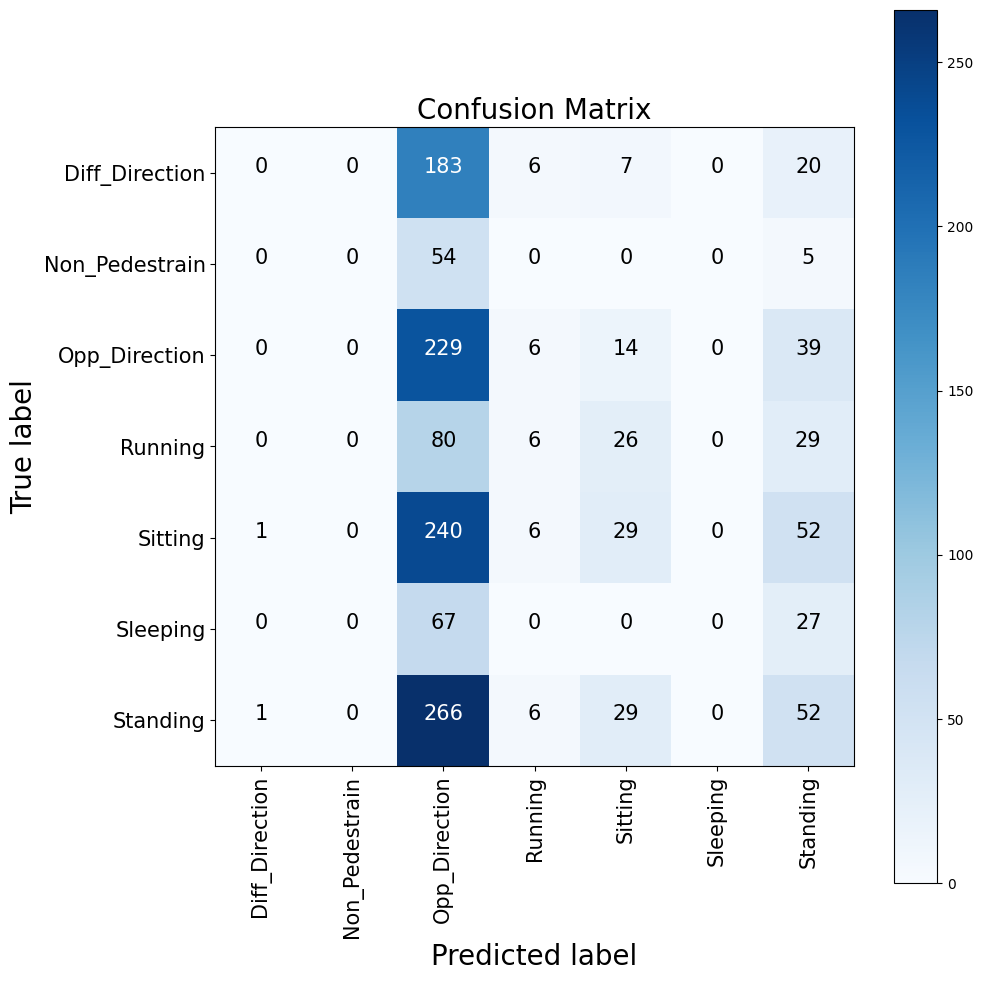

In [7]:
plot_confusion_matrix(cm=cm, classes=[label.strip() for label in LABELS], title='Confusion Matrix')

In [8]:
import os
if not os.path.isfile('models/CustomModel.h5'):
    model.save('models/CustomModel.h5')

c:\Users\NoobMaster69\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
# load model
from keras.models import load_model
model = load_model('models/CustomModel.h5')

# evaluate the model
loss, acc = model.evaluate(test_generator, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.214
